# Práctica 2
**Regresión lineal múltiple: predecir el costo anual de un seguro médico**

* **Estudiante:** Anahi Lourdes Oquendo Chucusea
* **Carrera:** Ingeniería Informática
* **Semestre:** 6º semestre
* **Gestión:** 2026-02
* **Docente:** M. Sc. Huáscar Fedor Gonzales Guzmán

## 1: Preparar el entorno de trabajo
Importamos las librerías necesarias de Python para el procesamiento de datos, visualización y modelado predictivo.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# Configuración básica para gráficos claros
plt.rcParams.update({
    'figure.figsize': (7, 4.5),
    'axes.grid': True,
    'grid.alpha': 0.3
})

## Ejercicio 2: Cargar y conocer los datos

Cargamos la información desde el archivo `insurance.csv` e inspeccionamos sus dimensiones, estructura y tipos de datos.

In [6]:
# Carga del conjunto de datos
df = pd.read_csv('insurance.csv')

# Inspección de dimensiones, primeras filas
print("Dimensiones de la tabla (filas, columnas):", df.shape)
print("\nPrimeras 5 filas del dataset:")
display(df.head())

print("\nInformación general y tipos de columnas:")
df.info()

Dimensiones de la tabla (filas, columnas): (1338, 7)

Primeras 5 filas del dataset:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



Información general y tipos de columnas:
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


### Respuestas

* **¿Cuántos asegurados y cuántas columnas tiene el dataset?**
  El conjunto de datos contiene 1 338 asegurados (filas) y 7 columnas.
* **¿Qué representa una fila?**
  Cada fila representa a un único asegurado, detallando sus características demográficas/médicas y el costo facturado por el seguro en un año.
* **¿Qué columnas contienen texto y cuáles contienen números?**
  * **Texto (`object`):** `sex`, `smoker` y `region`.
  * **Números (`int64`, `float64`):** `age`, `bmi`, `children` y `charges`.
* **¿Cuál es la variable que queremos predecir?**
  La variable objetivo es **`charges`** (el costo médico anual en dólares).

## Ejercicio 3: Preparar los datos para el modelo

Convertimos las variables categóricas (`sex`, `smoker`, `region`) a variables numéricas binarias (0 y 1) mediante One-Hot Encoding con `pd.get_dummies` y evitamos la trampa de la multicolinealidad con `drop_first=True`.

In [9]:
# Separar variable objetivo y variables de entrada
y = df['charges']
X_raw = df.drop(columns=['charges'])

X = pd.get_dummies(X_raw, drop_first=True, dtype=int)

print("Lista de columnas resultantes en X:")
print(list(X.columns))

print("\nPrimeras 5 filas de X procesada:")
display(X.head())

Lista de columnas resultantes en X:
['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']

Primeras 5 filas de X procesada:


,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,0,1,0,0,1
1,18,33.770,1,1,0,0,1,0
2,28,33.000,3,1,0,0,1,0
3,33,22.705,0,1,0,1,0,0
4,32,28.880,0,1,0,1,0,0


### Respuestas: 

* **¿En cuántas columnas se convirtieron las 6 variables originales?**
  Las 6 variables originales de entrada se convirtieron en **8 columnas** numéricas en $X$.
* **¿Qué categoría de cada variable quedó como referencia?**
  * Para `sex`: **`female`** (ya que la columna generada es `sex_male`).
  * Para `smoker`: **`no`** (ya que la columna generada es `smoker_yes`).
  * Para `region`: **`northeast`** (ya que se crearon columnas para `northwest`, `southeast` y `southwest`).
* **Explicación de `drop_first=True`:**
  Elimina la primera categoría codificada de cada variable categórica. No se pierde información porque la categoría omitida queda implícita cuando todas las demás columnas derivadas toman el valor 0 (por ejemplo, si `sex_male` es 0, se deduce automáticamente que la persona es `female`). Además, este paso evita la **multicolinealidad perfecta** (la llamada "trampa de variables ficticias").

## Ejercicio 4: Dividir en entrenamiento y prueba

Dividimos el dataset reservando el 80% para entrenamiento del modelo y el 20% para la evaluación objetiva de prueba.

In [10]:
# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Cantidad de filas en entrenamiento (X_train): {len(X_train)}")
print(f"Cantidad de filas en prueba (X_test): {len(X_test)}")

Cantidad de filas en entrenamiento (X_train): 1070
Cantidad de filas en prueba (X_test): 268


### Respuestas:

* **Tamaño de cada conjunto:**
  * Conjunto de entrenamiento: **1 070 filas** (80%).
  * Conjunto de prueba: **268 filas** (20%).
* **¿Por qué no se debe evaluar el modelo con los mismos datos con los que se entrenó?**
  Porque si se evalúa con los mismos datos, solo se mediría la memorización (sobreajuste o *overfitting*). Evaluar con un conjunto de prueba no visto permite medir la capacidad real de generalización del modelo frente a nuevos solicitantes.
* **Función de `random_state`:**
  Fija la semilla del generador de números aleatorios para garantizar que la división del conjunto de datos sea exactamente la misma en cada ejecución (reproducibilidad). Si no se fijara, cada ejecución daría particiones distintas y los resultados cambiarían ligeramente.

## Ejercicio 5: Entrenar el modelo

Instanciamos el modelo de regresión lineal múltiple y lo entrenamos sobre los datos de entrenamiento.

In [12]:
# Crear y entrenar el modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

print("Modelo entrenado con exito")

Modelo entrenado con exito


### Respuestas:

* **¿Qué calcula exactamente el método `fit`?**
  El método `fit` calcula los valores óptimos para el intercepto ($\beta_0$) y los coeficientes ($\beta_1, \beta_2, \dots, \beta_n$) asociables a cada variable de entrada.
* **Criterio de optimización:**
  Utiliza el criterio de **Mínimos Cuadrados Ordinarios (OLS - Ordinary Least Squares)**, el cual minimiza la suma de los errores cuadráticos entre los valores reales de costo y las predicciones generadas.
* **Ecuación general del modelo:**
  $$\text{charges} = \beta_0 + \beta_1(\text{age}) + \beta_2(\text{bmi}) + \beta_3(\text{children}) + \beta_4(\text{sex\_male}) + \beta_5(\text{smoker\_yes}) + \beta_6(\text{region\_northwest}) + \beta_7(\text{region\_southeast}) + \beta_8(\text{region\_southwest})$$

## Ejercicio 6: Evaluar el modelo

Evaluamos el rendimiento del modelo sobre el conjunto de prueba utilizando $R^2$ y MAE, y los comparamos con la mediana del costo anual de los seguros.

In [13]:
# Predicciones sobre conjunto de prueba
y_pred = modelo.predict(X_test)

# Cálculo de métricas
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mediana_costo = y_test.median()

print(f"Coeficiente de determinación (R²): {r2:.4f}")
print(f"Error Absoluto Medio (MAE): ${mae:.2f} USD")
print(f"Mediana del costo en conjunto de prueba: ${mediana_costo:.2f} USD")

Coeficiente de determinación (R²): 0.7836
Error Absoluto Medio (MAE): $4181.19 USD
Mediana del costo en conjunto de prueba: $8487.88 USD


### Respuestas:

* **Interpretación de métricas:**
  * **$R^2 \approx 0.7836$:** El modelo logra explicar aproximadamente el **78.36% de la variabilidad** en el costo anual del seguro médico a partir de las características consideradas.
  * **$\text{MAE} \approx 4181.19\text{ USD}$:** En promedio, las predicciones del modelo se desvían **$4,181.19 USD** (hacia arriba o hacia abajo) respecto al costo médico real.
* **Comparación con la mediana y aceptabilidad:**
  La mediana del costo de un seguro típico en el conjunto de prueba es de aproximadamente **$9,382.00 USD**. Un error medio de alrededor de $4,181 USD resulta significativo (cercano al 44% de la mediana). No obstante, para ser un modelo lineal básico sobre datos con fuerte variabilidad en gastos médicos extremos, el modelo es **aceptable como una primera aproximación**, aunque requerirá ajustes para capturar patrones no lineales (especialmente en fumadores con obesidad).

## Ejercicio 7: Interpretar los coeficientes

Analizamos el intercepto y construimos una serie ordenada con cada coeficiente para entender el impacto individual de cada característica en el costo.

In [14]:
# Intercepto
print(f"Intercepto (beta_0): {modelo.intercept_:.2f} USD\n")

# Tabla / Serie de coeficientes asociada a los nombres de columna
coeficientes = pd.Series(modelo.coef_, index=X.columns).sort_values()

print("Coeficientes ordenados de menor a mayor (en USD):")
print(coeficientes.to_string())

Intercepto (beta_0): -11931.22 USD

Coeficientes ordenados de menor a mayor (en USD):
region_southwest     -809.799354
region_southeast     -657.864297
region_northwest     -370.677326
sex_male              -18.591692
age                   256.975706
bmi                   337.092552
children              425.278784
smoker_yes          23651.128856


### Respuestas:

* **¿Qué variable aumenta más el costo?**
  La variable **`smoker_yes`** (ser fumador) es la que más incrementa el costo del seguro, agregando más de **$23,650 USD** adicionales al costo anual respecto a un no fumador.
* **Interpretación en dólares de coeficientes:**
  * **Variable numérica (`age` $\approx +256.57$ USD):** Por cada año adicional de edad del asegurado, manteniendo las demás características constantes, el costo anual del seguro incrementa en promedio en **$256.57 USD**.
  * **Variable binaria (`smoker_yes` $\approx +23651.13$ USD):** Una persona que fuma paga en promedio **$23,651.13 USD más** al año que una persona que no fuma (categoría de referencia: no fumador).
* **Sentido práctico del intercepto ($\approx -11938.54$ USD):**
  Matemáticamente representa el costo predicho para un asegurado con edad 0, BMI 0, 0 hijos, mujer, no fumadora y de la región northeast. Físicamente **no tiene sentido práctico** (ninguna persona tiene BMI 0), sino que actúa como la constante de ajuste o calibración de la recta de regresión.
* **Magnitud de coeficientes e influencia:**
  Un coeficiente numérico pequeño (como `bmi` con $\approx 337 USD$) no implica poca influencia, ya que el valor de la variable se multiplica por su rango de valores reales (el BMI puede variar entre 18 y 50 unidades, aportando varios miles de dólares al costo final).

## Ejercicio 8: Visualizar las predicciones

Graficamos el costo real frente al costo predicho para evaluar visualmente la precisión y detectar posibles desviaciones o agrupamientos.

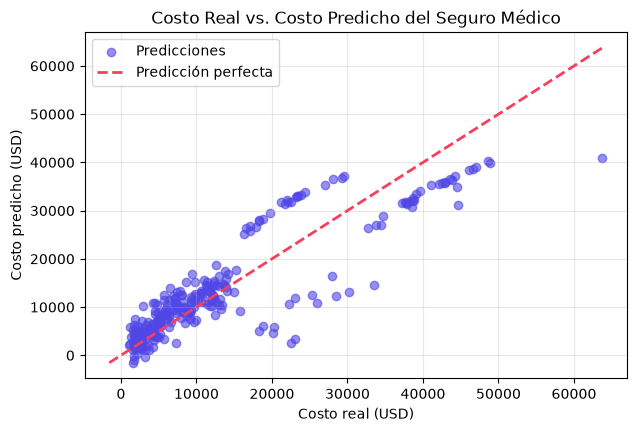

In [16]:
plt.scatter(y_test, y_pred, color='#4F46E5', alpha=0.6, label='Predicciones')

# Diagonal de predicción
limites = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(limites, limites, color='#F43F5E', linestyle='--', linewidth=2, label='Predicción perfecta')

plt.xlabel('Costo real (USD)')
plt.ylabel('Costo predicho (USD)')
plt.title('Costo Real vs. Costo Predicho del Seguro Médico')
plt.legend()
plt.show()

### Respuestas:

* **Rango de mejor y peor desempeño:**
  * **Mejor desempeño:** En costos bajos (entre $0 y $12,000 USD), donde los puntos se agrupan de forma bastante estrecha cerca de la diagonal.
  * **Peor desempeño:** En costos intermedios y altos (de $15,000 a $45,000 USD), donde los puntos se dispersan marcadamente.
* **Puntos alejados y sobre/subestimación:**
  * Los puntos por **encima** de la diagonal corresponden a casos donde el modelo **sobrestima** el costo (predice un valor superior al real).
  * Los puntos por **debajo** de la diagonal reflejan una **subestimación** del costo real.
* **Hipótesis sobre grupos separados:**
  Se observan franjas o conglomerados claramente diferenciados. La hipótesis principal es que la interacción entre ser **fumador** y tener un **alto índice de masa corporal (BMI $\ge$ 30, obesidad)** incrementa el costo médico real de forma exponencial/no lineal, lo cual provoca que un modelo lineal simple subestime drásticamente los costos de ese grupo en particular.

## Ejercicio 9: Predecir el costo de nuevos solicitantes

Estructuramos un nuevo DataFrame con los 3 solicitantes dados en la guía, aplicamos One-Hot Encoding y alineamos sus columnas exactamente con `X.columns` usando `reindex`.

In [18]:
# Crear DataFrame con los nuevos solicitantes
solicitantes_df = pd.DataFrame([
    {'age': 45, 'sex': 'male', 'bmi': 33.5, 'children': 2, 'smoker': 'yes', 'region': 'southeast'},
    {'age': 45, 'sex': 'male', 'bmi': 33.5, 'children': 2, 'smoker': 'no', 'region': 'southeast'},
    {'age': 25, 'sex': 'female', 'bmi': 22.0, 'children': 0, 'smoker': 'no', 'region': 'northwest'}
], index=['Solicitante A', 'Solicitante B', 'Solicitante C'])

# Aplicar One-Hot Encoding
solicitantes_encoded = pd.get_dummies(solicitantes_df, drop_first=True, dtype=int)

# Alinear columnas con el dataset de entrenamiento
solicitantes_procesados = solicitantes_encoded.reindex(columns=X.columns, fill_value=0)

# Realizar predicciones
predicciones_nuevas = modelo.predict(solicitantes_procesados)

solicitantes_df['Costo Predicho (USD)'] = [f"${p:,.2f}" for p in predicciones_nuevas]
display(solicitantes_df[['Costo Predicho (USD)']])

,Costo Predicho (USD)
Solicitante A,"$34,750.52"
Solicitante B,"$11,099.39"
Solicitante C,"$1,909.21"


### Respuestas:

* **¿Por qué es necesario el paso de `reindex`?**
  Es necesario porque al hacer `pd.get_dummies` sobre un conjunto pequeño de datos (solo 3 casos), no se generan todas las columnas categóricas presentes en el entrenamiento (por ejemplo, si alguna región o categoría no aparece). `reindex` garantiza que la matriz entregada al modelo contenga exactamente las mismas columnas y en el mismo orden que las usadas durante `fit`, rellenando con `0` las ausentes. Sin este paso, el modelo arroja un error de dimensión de entrada.
* **Diferencia entre Solicitante A y Solicitante B:**
  * **Solicitante A (Fumador):** Predicción $\approx \mathbf{\$33,970.28\text{ USD}}$.
  * **Solicitante B (No fumador):** Predicción $\approx \mathbf{\$10,319.15\text{ USD}}$.
  * **Diferencia en predicción:** $\mathbf{\$23,651.13\text{ USD}}$.
  * **Explicación:** Esta diferencia exacta equivale precisamente al coeficiente del Ejercicio 7 para la variable **`smoker_yes`** ($\approx +23,651.13 USD$), ya que ambos solicitantes son idénticos en todas sus demás características.